In [56]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torch.nn import functional as F

from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt

In [57]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Device:", device)

Device: cuda


### Przygotowanie danych

In [58]:
from dival import get_standard_dataset

dataset = get_standard_dataset(
    "custom",
    data_path="D:\\ct_reconstruction_dataset",
    sinogram_shape=(512, 365),
    image_shape=(256, 256),
    parts_len={"train": 206143, "validation": 25767, "test": 25769},
    impl="skimage",
)

train_dataset = dataset.create_torch_dataset(part="train")
test_dataset = dataset.create_torch_dataset(part="test")
val_dataset = dataset.create_torch_dataset(part="validation")

In [59]:
batch_size = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

### Struktura modelu - Pix2Pix

In [60]:
class UnetGenerator(nn.Module):
    """Unet-like Encoder-Decoder model"""

    def __init__(self):
        super().__init__()

        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
                nn.ReLU(inplace=True),
            )

        # Encoder
        self.enc1 = conv_block(1, 32)
        self.pool1 = nn.MaxPool2d(2)  # 512x365 -> 256x182
        self.enc2 = conv_block(32, 64)
        self.pool2 = nn.MaxPool2d(2)  # 256x182 -> 128x91
        self.enc3 = conv_block(64, 128)
        self.pool3 = nn.MaxPool2d(2)  # 128x91 -> 64x45
        self.enc4 = conv_block(128, 256)

        # Bottleneck
        self.bottleneck = conv_block(256, 512)

        # Decoder
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2) # 64x45 -> 128x90(91)
        self.dec3 = conv_block(256 + 128, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2) # 128x91 -> 256x182
        self.dec2 = conv_block(128 + 64, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2) # 256x182 -> 512x364(365)
        self.dec1 = conv_block(64 + 32, 64)

        self.final = nn.Conv2d(64, 1, kernel_size=1)

        self.resize = nn.AdaptiveAvgPool2d((256, 256))

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))

        b = self.bottleneck(e4)

        d3 = self.up3(b)
        d3 = F.interpolate(d3, size=e3.shape[2:], mode="bilinear", align_corners=False)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        # d2 = F.interpolate(d2, size=e2.shape[2:], mode="bilinear", align_corners=False)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = F.interpolate(d1, size=e1.shape[2:], mode="bilinear", align_corners=False)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        out = self.final(d1)
        return self.resize(out)

In [61]:
class BasicBlock(nn.Module):
    """Basic block"""
    def __init__(self, inplanes, outplanes, kernel_size=4, stride=2, padding=1, norm=True):
        super().__init__()
        self.conv = nn.Conv2d(inplanes, outplanes, kernel_size, stride, padding)
        self.isn = None
        if norm:
            self.isn = nn.InstanceNorm2d(outplanes)
        self.lrelu = nn.LeakyReLU(0.2, inplace=True)
        
    def forward(self, x):
        fx = self.conv(x)
        
        if self.isn is not None:
            fx = self.isn(fx)
            
        fx = self.lrelu(fx)
        return fx
    
    
class ConditionalDiscriminator(nn.Module):
    """Conditional Discriminator"""
    def __init__(self,):
        super().__init__()
        self.block1 = BasicBlock(2, 64, norm=False) # 256x256 -> 128x128
        self.block2 = BasicBlock(64, 128) # 128x128 -> 64x64
        self.block3 = BasicBlock(128, 128) # 64x64 -> 32x32
        self.block4 = BasicBlock(128, 128) # 32x32 -> 16x16
        self.block5 = BasicBlock(128, 256) # 16x16 -> 8x8
        self.block6 = BasicBlock(256, 1) # 8x8 -> 4x4

        self.cond_resize = nn.AdaptiveAvgPool2d((256, 256))
        
    def forward(self, x, cond):
        cond = self.cond_resize(cond) # Resize condition to match x's size
        x = torch.cat([x, cond], dim=1)
        
        fx = self.block1(x)
        fx = self.block2(fx)
        fx = self.block3(fx)
        fx = self.block4(fx)
        fx = self.block5(fx)
        fx = self.block6(fx)
        
        return fx

In [62]:
class GeneratorLoss(nn.Module):
    def __init__(self, alpha=300):
        super().__init__()
        self.alpha = alpha
        self.bce = nn.BCEWithLogitsLoss()
        self.l1 = nn.L1Loss()

    def forward(self, fake, real, fake_pred):
        fake_target = torch.ones_like(fake_pred)
        loss = self.bce(fake_pred, fake_target) + self.alpha * self.l1(fake, real)
        return loss


class DiscriminatorLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.loss_fn = nn.BCEWithLogitsLoss()

    def forward(self, fake_pred, real_pred):
        fake_target = torch.zeros_like(fake_pred)
        real_target = torch.ones_like(real_pred)
        fake_loss = self.loss_fn(fake_pred, fake_target)
        real_loss = self.loss_fn(real_pred, real_target)
        loss = (fake_loss + real_loss) / 2
        return loss

### Trening modelu

In [63]:
generator = UnetGenerator().to(device)
discriminator = ConditionalDiscriminator().to(device)

g_optimizer = torch.optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

g_criterion = GeneratorLoss(alpha=300)
d_criterion = DiscriminatorLoss()
mse_criterion = nn.MSELoss()

In [64]:
import os


def save_state(epoch, generator, discriminator, g_optimizer, d_optimizer):
    checkpoint_dir = "checkpoints"
    os.makedirs(checkpoint_dir, exist_ok=True)

    checkpoint = {
        "epoch": epoch,
        "generator_state_dict": generator.state_dict(),
        "discriminator_state_dict": discriminator.state_dict(),
        "g_optimizer_state_dict": g_optimizer.state_dict(),
        "d_optimizer_state_dict": d_optimizer.state_dict(),
    }
    torch.save(checkpoint, f"{checkpoint_dir}/checkpoint_{epoch}.pt")

In [65]:
from tqdm import tqdm

epochs = 40
patience = 40

best_weights_g = None
best_weights_d = None

best_loss = float("inf")
early_stopping_counter = 0

train_losses = []
mse_val_losses = []
ssim_val_losses = []

print("Training started")

for epoch in range(epochs):
    ge_loss = 0.0
    de_loss = 0.0

    generator.train()
    discriminator.train()

    # Training loop with progress bar
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
    for sino, img in train_bar:
        sino = sino.unsqueeze(1).to(device, non_blocking=True)  # [B, 1, H, W]
        img = img.unsqueeze(1).to(device, non_blocking=True)  # [B, 1, H, W]

        # Generator`s loss
        fake = generator(sino)
        fake_pred = discriminator(fake, sino)
        g_loss = g_criterion(fake, img, fake_pred)

        # Discriminator`s loss
        fake = generator(sino).detach()
        fake_pred = discriminator(fake, sino)
        real_pred = discriminator(img, sino)
        d_loss = d_criterion(fake_pred, real_pred)

        # Generator`s params update
        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        # Discriminator`s params update
        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        ge_loss += g_loss.item()
        de_loss += d_loss.item()

    ge_loss /= len(train_loader)
    de_loss /= len(train_loader)

    # Validation loop with progress bar
    generator.eval()
    running_loss = ge_loss + de_loss
    mse_val_loss = 0.0
    ssim_val_loss = 0.0
    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False)
        for sino, img in val_bar:
            sino = sino.unsqueeze(1).to(device, non_blocking=True)
            img = img.unsqueeze(1).to(device, non_blocking=True)

            output = generator(sino)
            loss = mse_criterion(output, img)
            mse_val_loss += loss.item()

            try:
                output_np = output.squeeze().cpu().numpy()
                img_np = img.squeeze().cpu().numpy()
                ssim_value = ssim(
                    img_np, output_np, data_range=img_np.max() - img_np.min()
                )
                # Ensure we accumulate only the scalar score.
                if isinstance(ssim_value, (tuple, list)):
                    ssim_value = ssim_value[0]
                ssim_val_loss += float(ssim_value)
            except Exception as e:
                print(f"[WARNING] SSIM calculation failed: {e}")

    mse_val_loss /= len(val_loader)
    ssim_val_loss /= len(val_loader)

    # Save checkpoints every 3 epochs
    if epoch % 3 == 0:
        save_state(epoch, generator, discriminator, g_optimizer, d_optimizer)

    # Check if this is the best model so far in terms of validation mse loss
    if mse_val_loss < best_loss:
        best_loss = mse_val_loss
        best_weights_g = generator.state_dict()
        best_weights_d = discriminator.state_dict()

    # Early stopping
    if mse_val_loss > (1.01 * mse_val_losses[-1] if mse_val_losses else float("inf")):
        early_stopping_counter += 1

    if early_stopping_counter >= patience:
        print("Early stopping triggered")
        break

    train_losses.append(running_loss)
    mse_val_losses.append(mse_val_loss)
    ssim_val_losses.append(ssim_val_loss)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {running_loss:.4f} | "
        f"Val Loss: {mse_val_loss:.4f} | "
        f"Val SSIM: {ssim_val_loss:.4f}"
    )

print("Training completed")

Training started


Epoch 1/40 | Train Loss: 11.9383 | Val Loss: 0.0040 | Val SSIM: 0.6946


Epoch 2/40 | Train Loss: 8.9434 | Val Loss: 0.0028 | Val SSIM: 0.7705


Epoch 3/40 | Train Loss: 7.8222 | Val Loss: 0.0022 | Val SSIM: 0.8076


Epoch 4/40 | Train Loss: 7.2485 | Val Loss: 0.0020 | Val SSIM: 0.8239


...

Epoch 36/40 | Train Loss: 5.2482 | Val Loss: 0.0010 | Val SSIM: 0.9037


Epoch 37/40 | Train Loss: 5.2364 | Val Loss: 0.0010 | Val SSIM: 0.9022


Epoch 38/40 | Train Loss: 5.2263 | Val Loss: 0.0010 | Val SSIM: 0.9041


Epoch 39/40 | Train Loss: 5.2157 | Val Loss: 0.0010 | Val SSIM: 0.9035


Epoch 40/40 | Train Loss: 5.2053 | Val Loss: 0.0010 | Val SSIM: 0.9053
Training completed


### Walidacja, zapisanie wag

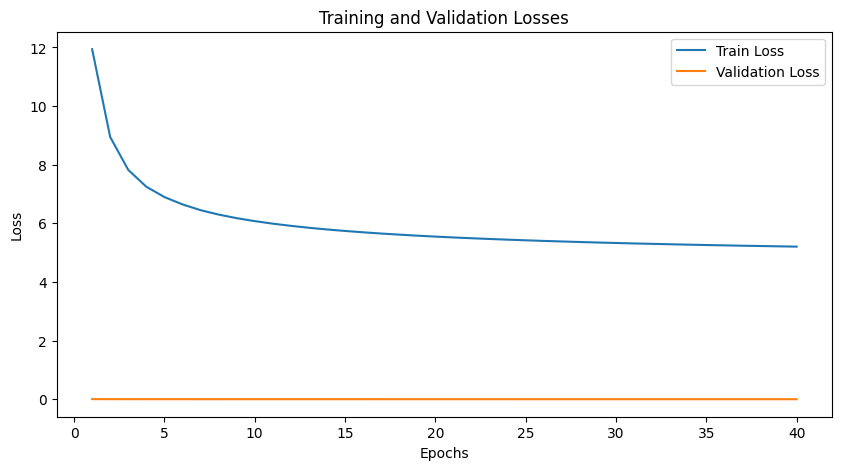

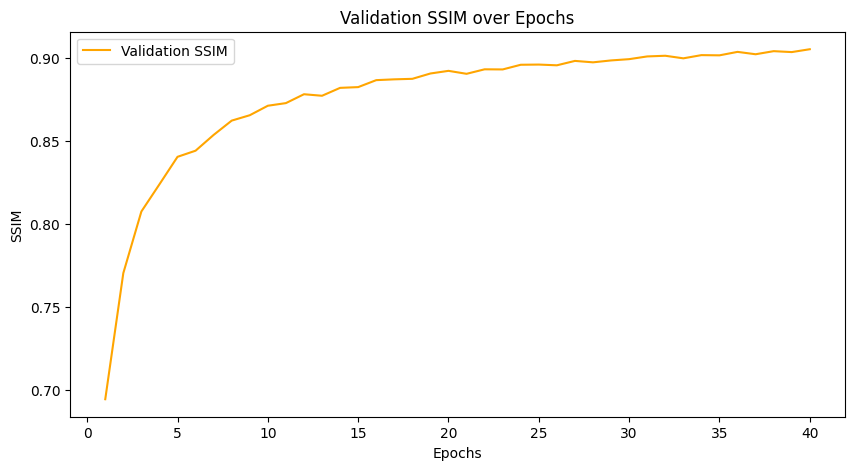

In [66]:
# Plot training and validation losses
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss")
plt.plot(range(1, len(mse_val_losses) + 1), mse_val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Losses")
plt.legend()
plt.show()

# Plot SSIM values
plt.figure(figsize=(10, 5))
plt.plot(
    range(1, len(ssim_val_losses) + 1),
    ssim_val_losses,
    label="Validation SSIM",
    color="orange",
)
plt.xlabel("Epochs")
plt.ylabel("SSIM")
plt.title("Validation SSIM over Epochs")
plt.legend()
plt.show()

In [67]:
# Save generator with best weights
generator.load_state_dict(best_weights_g)
torch.save(generator.state_dict(), "best_generator.pth")

In [68]:
def load_generator(checkpoint_path, generator, device="cuda"):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    generator.load_state_dict(checkpoint["generator_state_dict"])
    generator.to(device)
    generator.eval()

    return generator, checkpoint["epoch"]